In [1]:
import EOSutils as meos

import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cmx
from mpl_toolkits.axes_grid1 import make_axes_locatable

mpl.style.use('classic')

from astropy.table import Table
from astropy import units as u
from astropy.constants import G

import mesa_helper as mh
import os
import shutil
import copy

from scipy import ndimage, interpolate, optimize

from eos import aqua_eos, fe_eos
import pickle

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
def read_in_PALEOS(paleosfile):
    # code from Mara, https://zenodo.org/records/19661561

    # Grid parameters (adjust per table; see file headers)
    n_P, n_T = 1351, 380
    P_min, P_max = 1e5, 1e14       # Pa
    T_min, T_max = 300.0, 1e5      # K
    
    # Load data
    cols = ['P','T','rho','u','s','cp','cv','alpha','nabla_ad','phase']
    data = Table.read(paleosfile,format="ascii",header_start=0,data_start=1)

    # unit conversion: 
    # P [Pa]       -> P [erg/cm3]
    # rho [kg/m3]  -> rho [g/cm3]
    # u [J/kg]     -> u [
    # s [J/(kg·K)] -> s [

    P_min = P_min * 10
    P_max = P_max * 10

    data['P'] = data['P'] * 10
    data['rho'] = data['rho'] * 1.e-3
    data['u'] = data['u'] * 1.e4
    data['s'] = data['s'] * 1.e4

    paleostable = meos.simple_table()
    
    # Reconstruct full regular grid
    log10P = np.linspace(np.log10(P_min), np.log10(P_max), n_P)
    log10T = np.linspace(np.log10(T_min), np.log10(T_max), n_T)

    log10Tgrid, log10Pgrid = np.meshgrid(log10T, log10P)

    log10rhogrid = np.full((n_P, n_T), np.nan)
    log10Sgrid = np.full((n_P, n_T), np.nan)
    log10Egrid = np.full((n_P, n_T), np.nan)
    
    for row in data:
        i = np.searchsorted(log10P, np.log10(row['P']))
        j = np.searchsorted(log10T, np.log10(row['T']))
        if i < n_P and j < n_T:
            log10rhogrid[i, j] = np.log10(row['rho'])
            log10Sgrid[i, j] = np.log10(row['s'])
            log10Egrid[i, j] = np.log10(row['u'])

    paleostable.log10Pgrid = log10Pgrid
    paleostable.log10Tgrid = log10Tgrid
    paleostable.log10rhogrid = log10rhogrid
    paleostable.log10Sgrid = log10Sgrid
    paleostable.log10Egrid = log10Egrid
    
    # Interpolate (NaN propagates near missing points)
    #interp = interpolate.RegularGridInterpolator((log10P, log10T), rho)
    #rho_query = interp([[np.log10(100e9), np.log10(4000)]])[0]
    #print(type(rho_query))
    #print(np.shape(rho_query))
    return paleostable


In [3]:
ph2o = read_in_PALEOS("./PALEOS/paleos_water_eos_table_pt.dat")
prock = read_in_PALEOS("./PALEOS/paleos_mgsio3_eos_table_pt.dat")

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11533/1835842887.py:44: RuntimeWarning: invalid value encountered in log10
  log10Sgrid[i, j] = np.log10(row['s'])
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11533/1835842887.py:45: RuntimeWarning: invalid value encountered in log10
  log10Egrid[i, j] = np.log10(row['u'])


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1555: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=levels[i*nCol+j])


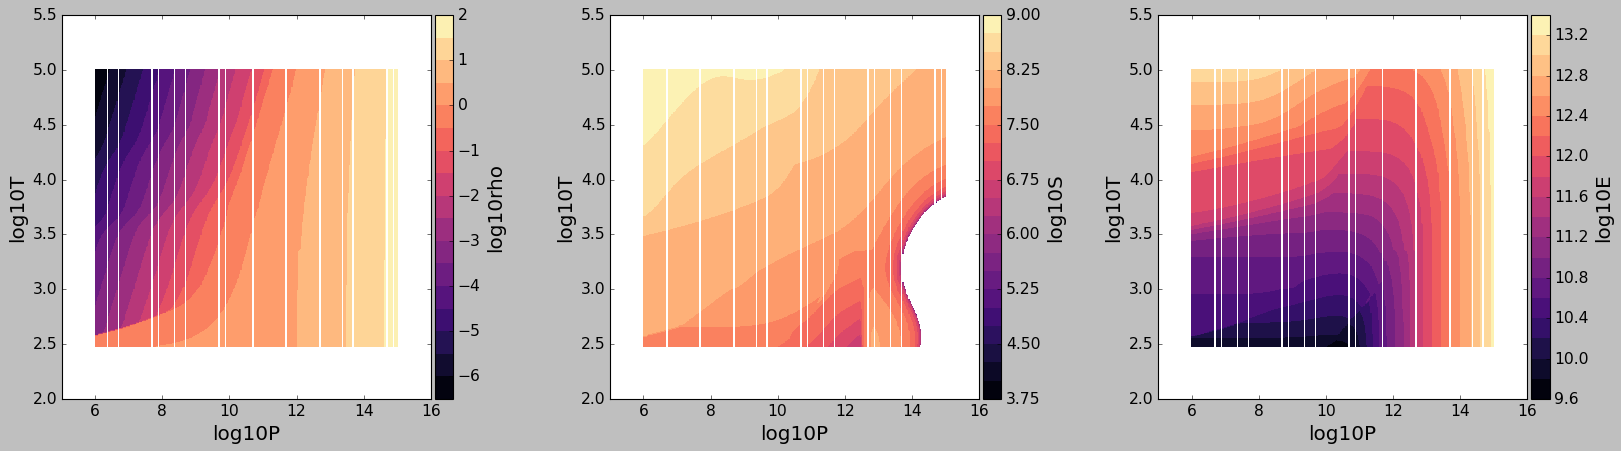

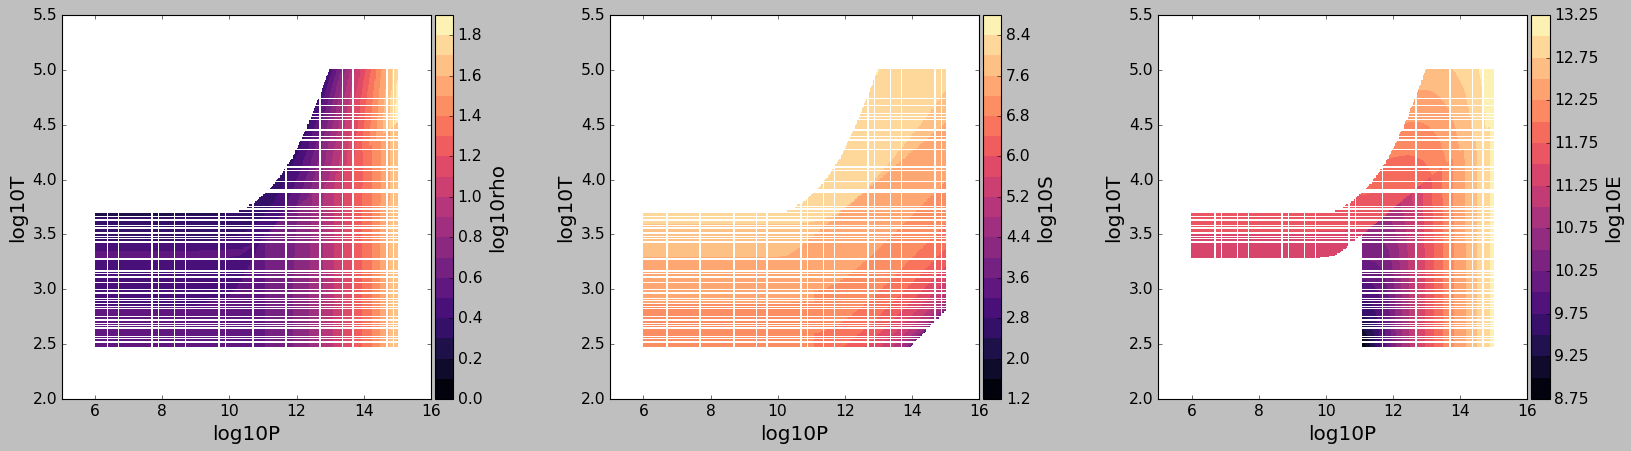

-6.442013446434289 1.6832140626252676
0.06543883931532374 1.8340408472329024


In [4]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=3,
                                      xs=ph2o.log10Pgrid, 
                                      ys=ph2o.log10Tgrid, 
                                      zs=[ph2o.log10rhogrid,ph2o.log10Sgrid,ph2o.log10Egrid],
                                      xlims=(5,16), 
                                      ylims=(2,5.5), 
                                      zlims=None, 
                                      levels=20, 
                                      xlabels='log10P', 
                                      ylabels='log10T', 
                                      zlabels=['log10rho','log10S','log10E'], 
                                      cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, species='H', plot_interpolation_lines=False, savename=None)

meos.contourf_subplots_with_colorbars(nRow=1, nCol=3,
                                      xs=prock.log10Pgrid, 
                                      ys=prock.log10Tgrid, 
                                      zs=[prock.log10rhogrid,prock.log10Sgrid,prock.log10Egrid],
                                      xlims=(5,16),
                                      ylims=(2,5.5), 
                                      zlims=None, 
                                      levels=20, 
                                      xlabels='log10P', 
                                      ylabels='log10T', 
                                      zlabels=['log10rho','log10S','log10E'], 
                                      cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, species='H', plot_interpolation_lines=False, savename=None)

print(np.min(ph2o.log10rhogrid[np.isfinite(ph2o.log10rhogrid)]), np.max(ph2o.log10rhogrid[np.isfinite(ph2o.log10rhogrid)]))
print(np.min(prock.log10rhogrid[np.isfinite(prock.log10rhogrid)]), np.max(prock.log10rhogrid[np.isfinite(prock.log10rhogrid)]))


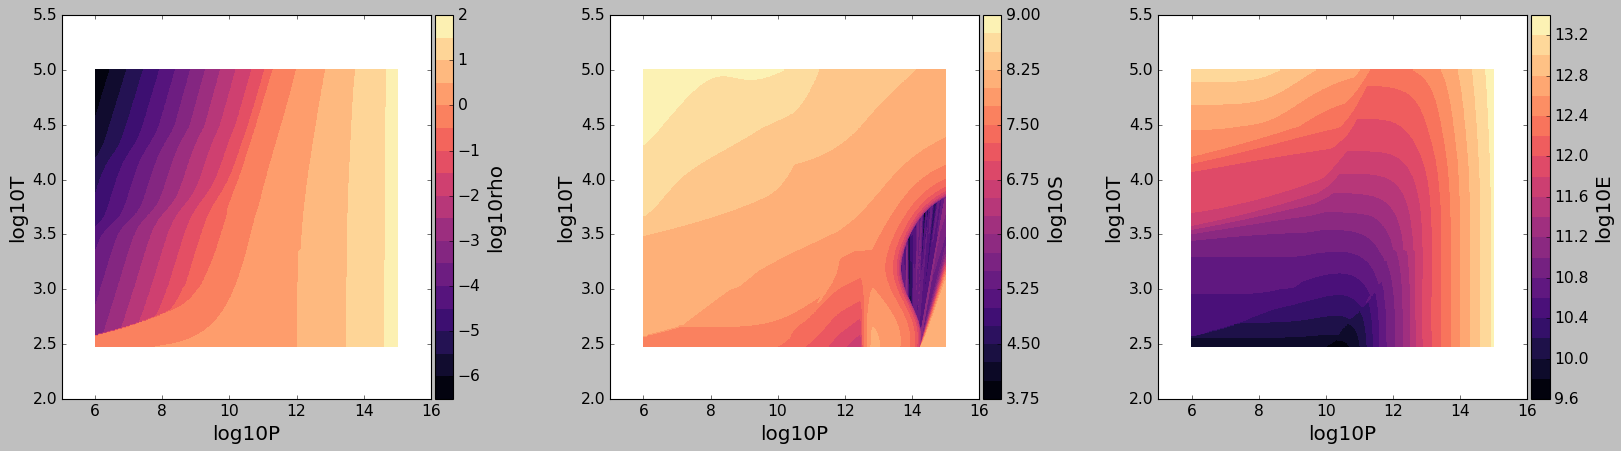

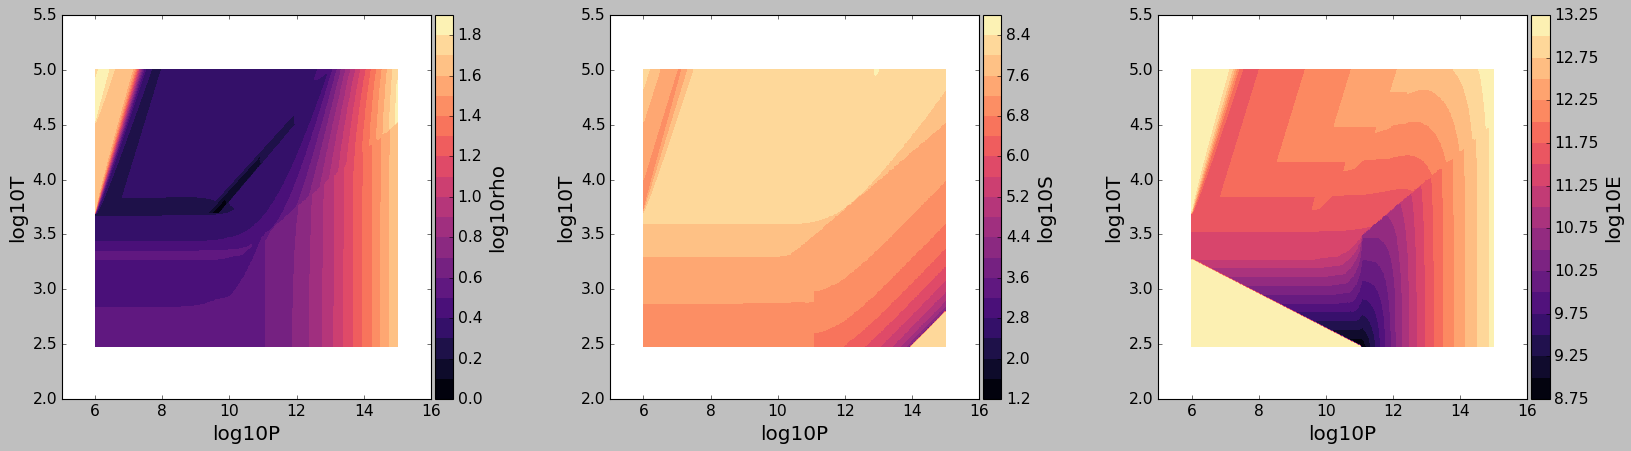

-6.442013446434289 1.6832140626252676
0.06543883931532374 1.8340408472329024


In [9]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=3,
                                      xs=ph2o.log10Pgrid, 
                                      ys=ph2o.log10Tgrid, 
                                      zs=[meos.fill_in_nans_PT(ph2o.log10rhogrid,ph2o),meos.fill_in_nans_PT(ph2o.log10Sgrid,ph2o),meos.fill_in_nans_PT(ph2o.log10Egrid,ph2o)],
                                      xlims=(5,16), 
                                      ylims=(2,5.5), 
                                      zlims=None, 
                                      levels=20, 
                                      xlabels='log10P', 
                                      ylabels='log10T', 
                                      zlabels=['log10rho','log10S','log10E'], 
                                      cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, species='H', plot_interpolation_lines=False, savename=None)

meos.contourf_subplots_with_colorbars(nRow=1, nCol=3,
                                      xs=prock.log10Pgrid, 
                                      ys=prock.log10Tgrid, 
                                      zs=[meos.fill_in_nans_PT(prock.log10rhogrid,prock),meos.fill_in_nans_PT(prock.log10Sgrid,prock),meos.fill_in_nans_PT(prock.log10Egrid,prock)],
                                      xlims=(5,16),
                                      ylims=(2,5.5), 
                                      zlims=None, 
                                      levels=20, 
                                      xlabels='log10P', 
                                      ylabels='log10T', 
                                      zlabels=['log10rho','log10S','log10E'], 
                                      cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, species='H', plot_interpolation_lines=False, savename=None)

print(np.min(ph2o.log10rhogrid[np.isfinite(ph2o.log10rhogrid)]), np.max(ph2o.log10rhogrid[np.isfinite(ph2o.log10rhogrid)]))
print(np.min(prock.log10rhogrid[np.isfinite(prock.log10rhogrid)]), np.max(prock.log10rhogrid[np.isfinite(prock.log10rhogrid)]))


In [10]:
# reinterpolate PALEOS grids to (rho,T)
def PALEOS_change_coords(paleostable, desired_rhoarr, desired_Tarr):
    start_Parr = paleostable.log10Pgrid[:,0]
    start_Tarr = paleostable.log10Tgrid[0]

    rhoT_table = meos.simple_table()

    rhoT_table.log10Tgrid, rhoT_table.log10rhogrid = np.meshgrid(desired_Tarr, desired_rhoarr)
    #print(rhoT_table.log10rhogrid[:,0])
    #print(rhoT_table.log10Tgrid[0])

    # construct an interpolator to get rho as a function of (P, T)
    interp_log10rho_given_log10P_log10T = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=meos.fill_in_nans_PT(paleostable.log10rhogrid,paleostable), bounds_error=False, fill_value=None, method='linear')

    def log10rho_abs_diff(log10P, log10rho, log10T):
        return np.abs(log10rho - interp_log10rho_given_log10P_log10T((log10P,log10T)))

    # construct interpolators to get S and E as functions of (P,T)
    interp_log10S_given_log10P_log10T = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=meos.fill_in_nans_PT(paleostable.log10Sgrid,paleostable), bounds_error=False, fill_value=None, method='linear')
    interp_log10E_given_log10P_log10T = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=meos.fill_in_nans_PT(paleostable.log10Egrid,paleostable), bounds_error=False, fill_value=None, method='linear')
        
    def solve_log10PSE(log10rho, log10T, log10P0=6.):
        opt = optimize.minimize(log10rho_abs_diff, x0=log10P0, args=(log10rho,log10T),bounds=[(5.95,16.05)], tol=1.e-10) #lower and upper bounds on rho come from np.min, max of np.log10(maz_cepam_rhogrid)
        opt_log10P = opt.x[0]
        
        corresponding_log10S = interp_log10S_given_log10P_log10T((opt_log10P, log10T))
        corresponding_log10E = interp_log10E_given_log10P_log10T((opt_log10P, log10T))
        return opt_log10P, corresponding_log10S, corresponding_log10E

    # interpolate!
    log10Pgrid_interpolated = np.zeros_like(rhoT_table.log10Tgrid)
    log10Sgrid_interpolated = np.zeros_like(rhoT_table.log10Tgrid)
    log10Egrid_interpolated = np.zeros_like(rhoT_table.log10Tgrid)
        
    for i in range(np.shape(rhoT_table.log10Tgrid)[1]):
        this_log10T = rhoT_table.log10Tgrid[0][i]
        for j in range(np.shape(rhoT_table.log10rhogrid)[0]):
            this_log10rho = rhoT_table.log10rhogrid[:,0][j]
        
            interpolated_log10P, interpolated_log10S, interpolated_log10E  = solve_log10PSE(log10rho=this_log10rho, log10T=this_log10T, log10P0=6.)
        
            log10Pgrid_interpolated[j,i] = interpolated_log10P
            log10Sgrid_interpolated[j,i] = interpolated_log10S
            log10Egrid_interpolated[j,i] = interpolated_log10E

            rhoT_table.log10Pgrid = log10Pgrid_interpolated
            rhoT_table.log10Sgrid = log10Sgrid_interpolated
            rhoT_table.log10Egrid = log10Egrid_interpolated
            rhoT_table.log10Ugrid = rhoT_table.log10Egrid
    
    return rhoT_table

In [11]:
ph2o_rhoT = PALEOS_change_coords(paleostable=ph2o, desired_rhoarr=np.arange(-6.,1.66,0.05), desired_Tarr=np.arange(2.,5.01,0.05))
prock_rhoT = PALEOS_change_coords(paleostable=prock, desired_rhoarr=np.arange(0.05,1.81,0.05), desired_Tarr=np.arange(2.,5.01,0.05))

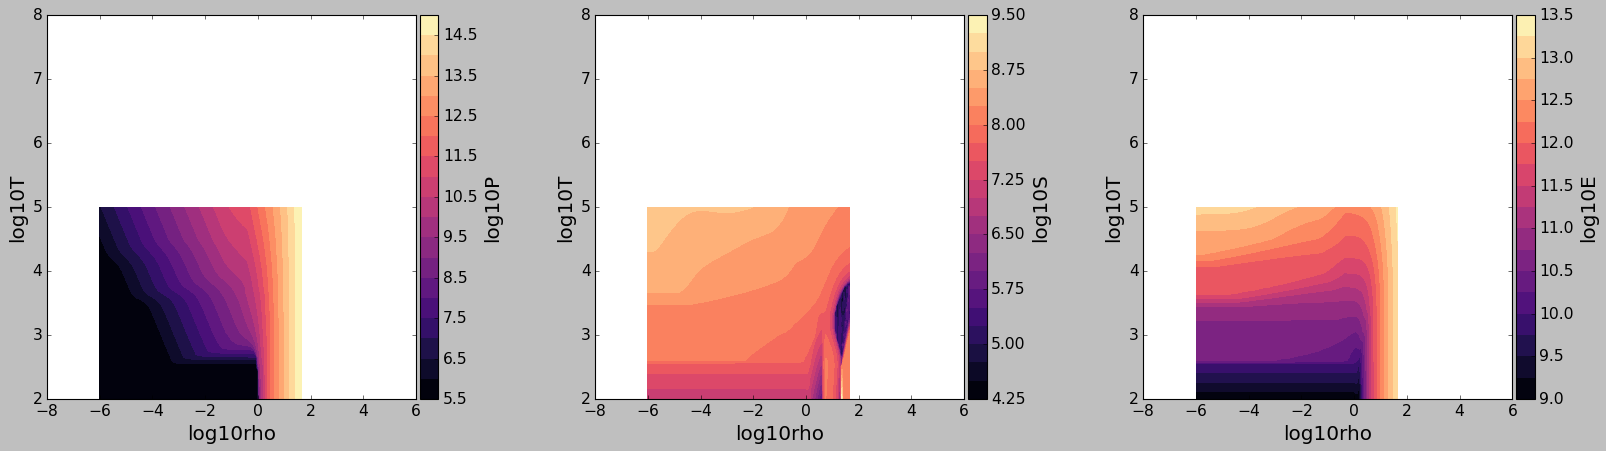

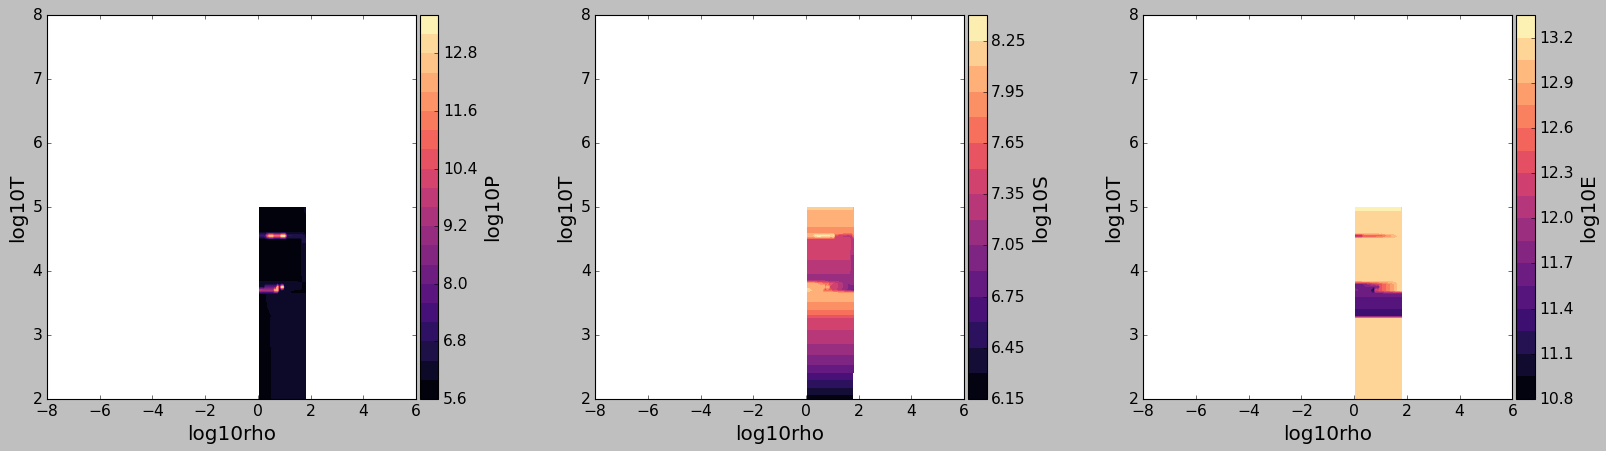

5.95 14.976624271491437
5.95 13.478557153598274


In [13]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=3,
                                      xs=ph2o_rhoT.log10rhogrid, 
                                      ys=ph2o_rhoT.log10Tgrid, 
                                      zs=[ph2o_rhoT.log10Pgrid,ph2o_rhoT.log10Sgrid,ph2o_rhoT.log10Egrid],
                                      xlims=(-8,6), 
                                      ylims=(2,8), 
                                      zlims=None, 
                                      levels=20, 
                                      xlabels='log10rho', 
                                      ylabels='log10T', 
                                      zlabels=['log10P','log10S','log10E'], 
                                      cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, species='H', plot_interpolation_lines=False, savename=None)

meos.contourf_subplots_with_colorbars(nRow=1, nCol=3,
                                      xs=prock_rhoT.log10rhogrid, 
                                      ys=prock_rhoT.log10Tgrid, 
                                      zs=[prock_rhoT.log10Pgrid,prock_rhoT.log10Sgrid,prock_rhoT.log10Egrid],
                                      xlims=(-8,6),
                                      ylims=(2,8), 
                                      zlims=None, 
                                      levels=20, 
                                      xlabels='log10rho', 
                                      ylabels='log10T', 
                                      zlabels=['log10P','log10S','log10E'], 
                                      cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, species='H', plot_interpolation_lines=False, savename=None)

print(np.min(ph2o_rhoT.log10Pgrid[np.isfinite(ph2o_rhoT.log10Pgrid)]), np.max(ph2o_rhoT.log10Pgrid[np.isfinite(ph2o_rhoT.log10Pgrid)]))
print(np.min(prock_rhoT.log10Pgrid[np.isfinite(prock_rhoT.log10Pgrid)]), np.max(prock_rhoT.log10Pgrid[np.isfinite(prock_rhoT.log10Pgrid)]))


In [25]:
def read_in_SESAME(sesamefile):
    """
    SESAME/ANEOS header looks like:

    # Material SS08 water
    # version_date                                                (YYYYMMDD)
    # num_rho  num_T
    # rho[0]   rho[1]  ...  rho[num_rho-1]                        (kg/m^3)
    # T[0]     T[1]    ...  T[num_T-1]                            (K)
    # u[0, 0]                 P[0, 0]     c[0, 0]     s[0, 0]     (J/kg, Pa, m/s, J/K/kg)
    # u[1, 0]                 ...         ...         ...
    # ...                     ...         ...         ...
    # u[num_rho-1, 0]         ...         ...         ...
    # u[0, 1]                 ...         ...         ...
    # ...                     ...         ...         ...
    # u[num_rho-1, num_T-1]   ...         ...         s[num_rho-1, num_T-1]
    20220714 
    275 218 
    """
    num_rho = None
    num_T = None

    
    with open(sesamefile) as file:
        for i,line in enumerate(file):
            if i==13:
                num_rho, num_T = line.split(" ")[:-1] #to avoid trailing newline
                num_rho = int(num_rho)
                num_T = int(num_T)
                rho_arr = np.zeros((num_rho))
                T_arr = np.zeros((num_T))
            if i==14:
                rho_list = line.split(" ")[:-1]
                for j in range(len(rho_list)):
                    rho_arr[j] = float(rho_list[j])
            if i==15:
                T_list = line.split(" ")[:-1]
                for j in range(len(T_list)):
                    T_arr[j] = float(T_list[j])
                break

    # num_rho is 275
    # num_T is 218
    rhogrid, Tgrid = np.meshgrid(rho_arr, T_arr) # (218, 275)

    Ugrid = np.zeros_like(rhogrid)
    Pgrid = np.zeros_like(rhogrid)
    Sgrid = np.zeros_like(rhogrid)

    data = np.genfromtxt(sesamefile, skip_header=16)
    #print(np.shape(data))

    for i in range(len(T_arr)):
        Ugrid[i] = data[:,0][i*num_rho : (i+1)*num_rho]
        Pgrid[i] = data[:,1][i*num_rho : (i+1)*num_rho]
        Sgrid[i] = data[:,3][i*num_rho : (i+1)*num_rho]

    # convert to cgs
    rhogrid = rhogrid * 1.e-3 # kg/m^3 to g/cm^3
    Ugrid = Ugrid * 1.e4      # J/kg to erg/g
    Pgrid = Pgrid * 10        # Pa to dyn/cm^2, aka erg/cm^3 
    Sgrid = Sgrid * 1.e4      # J/(kg*K) to erg/(g*K)

    # for SESAME only, not ANEOS
    # get rid of first column and first row, which correspond to density = 0, temperature = 0 respectively
    if "SESAME" in sesamefile or "SS08" in sesamefile:
        rhogrid = rhogrid[1:][:,1:]
        Tgrid = Tgrid[1:][:,1:]
        Ugrid = Ugrid[1:][:,1:]
        Pgrid = Pgrid[1:][:,1:]
        Sgrid = Sgrid[1:][:,1:]

    log10rhogrid = np.log10(rhogrid)
    log10Tgrid = np.log10(Tgrid)
    log10Ugrid = np.log10(Ugrid)
    log10Pgrid = np.log10(Pgrid)
    log10Sgrid = np.log10(Sgrid)
    return log10rhogrid, log10Tgrid, log10Ugrid, log10Pgrid, log10Sgrid
    

In [97]:
class SESAMEtable(object):
    def __init__(self, filename, units='cgs', **kwargs):
        self.filename = filename

        if units == 'cms' or units == 'cgs' or units == 'CMS':
            self.units = units
        else: 
            print('units must be cgs or mks or CMS (T [K], P [GPa], rho [g/cm^3], U [MJ/kg], S [MJ/kg/K])')
        
        self.Z = 1.
        self.X = 0.
        self.Y = 0.

        self.log10rhogrid, self.log10Tgrid, self.log10Ugrid, self.log10Pgrid, self.log10Sgrid = read_in_SESAME(filename)

        if self.units == 'CMS':
            self.log10Pgrid = self.log10Pgrid - 10 #convert to GPa for easy comparison with CMS19 (and recall this is a logarithmic quantity)
            self.log10Sgrid = self.log10Sgrid - 10 #convert to MJ kg^-1 K^-1 for easy comparison with CMS19 (and recall this is a logarithmic quantity)
            self.log10Ugrid = self.log10Ugrid - 10 #convert to MJ kg^-1 for easy comparison with CMS19 (and recall this is a logarithmic quantity)

        elif self.units == 'mks':
            self.log10Pgrid = self.log10Pgrid - 1 # convert P to Pa
            self.log10rhogrid = self.log10rhogrid + 3 # convert rho to kg m^-3
            self.log10Sgrid = self.log10Sgrid - 4 # convert S to J kg^-1 K^-1
            self.log10Ugrid = self.log10Ugrid - 4 # convert U to J kg^-1

        self.log10Egrid = self.log10Ugrid
                
        self.independent_arr_1 = np.unique(self.log10rhogrid[0]) #unique rho
        self.independent_arr_2 = np.unique(self.log10Tgrid[:,0]) #unique T

        self.independent_var_1 = 'rho'
        self.independent_var_2 = 'T'

        self.nrho = len(self.independent_arr_1)
        self.nT = len(self.independent_arr_2)
        

In [98]:
def read_in_AQUA(aquafile="/Users/emily/Documents/astro/giant_planets/MESA_EoS/eos/aqua/aqua_eos_rhot_v1_0.dat"):
    """
    # Label     Unit     Format  Description                                                                  
    #-----------------------------------------------------------------------------------------------#--------------------------------------
    # rho       kg/m^3   E14.8   Density     (1501 x log spaced)                                              
    # temp      K        E14.8   Temperature ( 301 x log spaced)                                              
    # press     Pa       E14.8   Pressure                                                                     
    # ad_grad   1        E14.8   Adiabatic temperature gradient, (dlog(T)/dlog(P))_S                          
    # s         J/(kg*K) E14.8   Specific entropy                                                             
    # u         J/kg     E14.8   Specific internal energy                                                     
    # c         m/s      E14.8   Bulk speed of sound                                                          
    # mmw       kg/mol   E14.8   Mean molecular weight                                                        
    # x_ion     1        E14.8   Ionization fraction   ( x_ion = N_e/N_tot )                                  
    # x_d       1        E14.8   Dissociation fraction ( x_d   = 1 - N_H2O/N_tot )                            
    # phase     1        I3      Phase id (vapor+ice: 0, vapor+liquid: 1, ice+liquid: 2, vapor: 3, #liquid: 4, supercritical+superionic: 5,
    #                            ice-Ih: -1, ice-II: -2, ice-III: -3, ice-V: -5, ice-VI:-6, ice-VII/#X: -7, ice-Ih+ice-II: -12,            
    #                            ice-Ih+ice-III: -13, ice-II+ice-III: -23, ice-II+ice-V: -25, ice-#II+ice-VI: -26,ice-III+ice-V: -35,      
    #                            ice-III+ice-VI: -36, ice-VI+ice-VII: -67, ice-X+superionic: -10)             
    """
    
    aquatable = np.genfromtxt(aquafile)

    rho_arr = np.unique(aquatable[:,0])
    T_arr = np.unique(aquatable[:,1])
    num_rho = len(rho_arr)
    num_T = len(T_arr)

    Tgrid, rhogrid = np.meshgrid(T_arr, rho_arr) #(1501, 301)

    Ugrid = np.zeros_like(rhogrid)
    Pgrid = np.zeros_like(rhogrid)
    Sgrid = np.zeros_like(rhogrid)

    for i in range(len(rho_arr)):
        Pgrid[i] = aquatable[:,2][i*num_T : (i+1)*num_T]
        Sgrid[i] = aquatable[:,4][i*num_T : (i+1)*num_T]
        Ugrid[i] = aquatable[:,5][i*num_T : (i+1)*num_T]

    # convert to cgs
    rhogrid = rhogrid * 1.e-3 # kg/m^3 to g/cm^3
    Ugrid = Ugrid * 1.e4      # J/kg to erg/g
    Pgrid = Pgrid * 10        # Pa to dyn/cm^2, aka erg/cm^3 
    Sgrid = Sgrid * 1.e4      # J/(kg*K) to erg/(g*K)
    
    log10rhogrid = np.log10(rhogrid)
    log10Tgrid = np.log10(Tgrid)
    log10Ugrid = np.log10(Ugrid)
    log10Pgrid = np.log10(Pgrid)
    log10Sgrid = np.log10(Sgrid)
   
    return log10rhogrid, log10Tgrid, log10Ugrid, log10Pgrid, log10Sgrid

In [99]:
class AQUAtable(object):
    def __init__(self, filename="/Users/emily/Documents/astro/giant_planets/MESA_EoS/AQUA/Tables/aqua_eos_rhot_v1_0.dat", units='cgs', **kwargs):
        self.filename = filename

        if units == 'cms' or units == 'cgs' or units == 'CMS':
            self.units = units
        else: 
            print('units must be cgs or mks or CMS (T [K], P [GPa], rho [g/cm^3], U [MJ/kg], S [MJ/kg/K])')
        
        self.Z = 1.
        self.X = 0.
        self.Y = 0.

        self.log10rhogrid, self.log10Tgrid, self.log10Ugrid, self.log10Pgrid, self.log10Sgrid = read_in_AQUA(filename)

        if self.units == 'CMS':
            self.log10Pgrid = self.log10Pgrid - 10 #convert to GPa for easy comparison with CMS19 (and recall this is a logarithmic quantity)
            self.log10Sgrid = self.log10Sgrid - 10 #convert to MJ kg^-1 K^-1 for easy comparison with CMS19 (and recall this is a logarithmic quantity)
            self.log10Ugrid = self.log10Ugrid - 10 #convert to MJ kg^-1 for easy comparison with CMS19 (and recall this is a logarithmic quantity)

        elif self.units == 'mks':
            self.log10Pgrid = self.log10Pgrid - 1 # convert P to Pa
            self.log10rhogrid = self.log10rhogrid + 3 # convert rho to kg m^-3
            self.log10Sgrid = self.log10Sgrid - 4 # convert S to J kg^-1 K^-1
            self.log10Ugrid = self.log10Ugrid - 4 # convert U to J kg^-1

        self.log10Egrid = self.log10Ugrid
        self.independent_arr_1 = np.unique(self.log10rhogrid[:,0]) #unique rho
        self.independent_arr_2 = np.unique(self.log10Tgrid[0]) #unique T
        
        self.independent_var_1 = 'rho'
        self.independent_var_2 = 'T'

        self.nrho = len(self.independent_arr_1)
        self.nT = len(self.independent_arr_2)

In [100]:
"""
class simple_table(object):
    def __init__(self, units='cgs', **kwargs):
        if units == 'cms' or units == 'cgs' or units == 'CMS':
            self.units = units
        else: 
            print('units must be cgs or mks or CMS (T [K], P [GPa], rho [g/cm^3], U [MJ/kg], S [MJ/kg/K])')

        self.X = None
        self.Y = None
        
        self.atomic_number = None
        self.mass_number = None

        self.log10Tgrid = None
        self.log10Pgrid = None
        self.log10rhogrid = None
        self.log10Sgrid = None
        self.log10Ugrid = None
"""

"\nclass simple_table(object):\n    def __init__(self, units='cgs', **kwargs):\n        if units == 'cms' or units == 'cgs' or units == 'CMS':\n            self.units = units\n        else: \n            print('units must be cgs or mks or CMS (T [K], P [GPa], rho [g/cm^3], U [MJ/kg], S [MJ/kg/K])')\n\n        self.X = None\n        self.Y = None\n        \n        self.atomic_number = None\n        self.mass_number = None\n\n        self.log10Tgrid = None\n        self.log10Pgrid = None\n        self.log10rhogrid = None\n        self.log10Sgrid = None\n        self.log10Ugrid = None\n"

In [101]:
# water
aqua = AQUAtable()
paqua = copy.deepcopy(ph2o_rhoT)
h2o = SESAMEtable("./SESAME_from_SWIFT/SESAME_water_7154.txt")
ss08 = SESAMEtable("./SESAME_from_SWIFT/SS08_water.txt")

#rock
basalt = SESAMEtable("./SESAME_from_SWIFT/SESAME_basalt_7530.txt")
iron_alloy = SESAMEtable("./ANEOS_from_SWIFT/ANEOS_Fe85Si15_S20.txt")
forsterite = SESAMEtable("./ANEOS_from_SWIFT/ANEOS_forsterite_S19.txt")

#iron
iron = SESAMEtable("./SESAME_from_SWIFT/SESAME_iron_2140.txt")
an_iron = SESAMEtable("./ANEOS_from_SWIFT/ANEOS_iron_S20.txt")



/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11533/944316498.py:49: RuntimeWarning: invalid value encountered in log10
  log10Sgrid = np.log10(Sgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11533/126481748.py:76: RuntimeWarning: invalid value encountered in log10
  log10Pgrid = np.log10(Pgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11533/126481748.py:77: RuntimeWarning: divide by zero encountered in log10
  log10Sgrid = np.log10(Sgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11533/126481748.py:77: RuntimeWarning: invalid value encountered in log10
  log10Sgrid = np.log10(Sgrid)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11533/126481748.py:76: RuntimeWarning: divide by zero encountered in log10
  log10Pgrid = np.log10(Pgrid)


In [102]:
print(np.min(paqua.log10Pgrid),np.max(paqua.log10Pgrid))
print(np.min(aqua.log10Pgrid),np.max(aqua.log10Pgrid))
print(np.min(h2o.log10Pgrid[np.isfinite(h2o.log10Pgrid)]), np.max(h2o.log10Pgrid[np.isfinite(h2o.log10Pgrid)]))
print(np.min(ss08.log10Pgrid[np.isfinite(ss08.log10Pgrid)]), np.max(ss08.log10Pgrid[np.isfinite(ss08.log10Pgrid)]))

5.95 14.976624271491437
-12.964305130929235 15.633260519139832
3.1306478010404994 20.54304766664149
-5.513930781906488 13.600494909905308


In [103]:
print(np.min(paqua.log10Sgrid),np.max(paqua.log10Sgrid))
print(np.min(aqua.log10Sgrid[np.isfinite(aqua.log10Sgrid)]),np.max(aqua.log10Sgrid[np.isfinite(aqua.log10Sgrid)]))
print(np.min(h2o.log10Sgrid[np.isfinite(h2o.log10Sgrid)]), np.max(h2o.log10Sgrid[np.isfinite(h2o.log10Sgrid)]))
print(np.min(ss08.log10Sgrid[np.isfinite(ss08.log10Sgrid)]), np.max(ss08.log10Sgrid[np.isfinite(ss08.log10Sgrid)]))

4.382444262803011 9.429071489404853
4.298442126756666 9.040944384345146
5.9275901512851705 9.291035128150154
-16.000000013897424 9.575040105390624


In [104]:
print(np.min(paqua.log10Egrid),np.max(paqua.log10Egrid))
print(np.min(aqua.log10Egrid[np.isfinite(aqua.log10Egrid)]),np.max(aqua.log10Egrid[np.isfinite(aqua.log10Egrid)]))
print(np.min(h2o.log10Egrid[np.isfinite(h2o.log10Egrid)]), np.max(h2o.log10Egrid[np.isfinite(h2o.log10Egrid)]))
print(np.min(ss08.log10Egrid[np.isfinite(ss08.log10Egrid)]), np.max(ss08.log10Egrid[np.isfinite(ss08.log10Egrid)]))

9.0632452129483 13.309371265146954
8.632558083375503 13.642280713449978
9.346328035058654 17.019404358627497
-13.0 13.016400662843466


In [105]:
print(aqua.log10Tgrid[0][56:66])
print(paqua.log10Tgrid[0])

[2.56 2.57 2.58 2.59 2.6  2.61 2.62 2.63 2.64 2.65]
[2.   2.05 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65
 2.7  2.75 2.8  2.85 2.9  2.95 3.   3.05 3.1  3.15 3.2  3.25 3.3  3.35
 3.4  3.45 3.5  3.55 3.6  3.65 3.7  3.75 3.8  3.85 3.9  3.95 4.   4.05
 4.1  4.15 4.2  4.25 4.3  4.35 4.4  4.45 4.5  4.55 4.6  4.65 4.7  4.75
 4.8  4.85 4.9  4.95 5.  ]


In [152]:
desired_rhoarr=np.arange(-8.0,6.04, 0.05)
print(len(desired_rhoarr))
print(desired_rhoarr[195:])
print(paqua.log10Tgrid[0])

281
[1.75 1.8  1.85 1.9  1.95 2.   2.05 2.1  2.15 2.2  2.25 2.3  2.35 2.4
 2.45 2.5  2.55 2.6  2.65 2.7  2.75 2.8  2.85 2.9  2.95 3.   3.05 3.1
 3.15 3.2  3.25 3.3  3.35 3.4  3.45 3.5  3.55 3.6  3.65 3.7  3.75 3.8
 3.85 3.9  3.95 4.   4.05 4.1  4.15 4.2  4.25 4.3  4.35 4.4  4.45 4.5
 4.55 4.6  4.65 4.7  4.75 4.8  4.85 4.9  4.95 5.   5.05 5.1  5.15 5.2
 5.25 5.3  5.35 5.4  5.45 5.5  5.55 5.6  5.65 5.7  5.75 5.8  5.85 5.9
 5.95 6.  ]
[2.   2.05 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65
 2.7  2.75 2.8  2.85 2.9  2.95 3.   3.05 3.1  3.15 3.2  3.25 3.3  3.35
 3.4  3.45 3.5  3.55 3.6  3.65 3.7  3.75 3.8  3.85 3.9  3.95 4.   4.05
 4.1  4.15 4.2  4.25 4.3  4.35 4.4  4.45 4.5  4.55 4.6  4.65 4.7  4.75
 4.8  4.85 4.9  4.95 5.  ]


In [153]:
desired_Tarr = np.arange(2.,8.04,0.05)
print(desired_Tarr[56:66])


[4.8  4.85 4.9  4.95 5.   5.05 5.1  5.15 5.2  5.25]


In [154]:
print(paqua.log10rhogrid[:,0])

[-6.00000000e+00 -5.95000000e+00 -5.90000000e+00 -5.85000000e+00
 -5.80000000e+00 -5.75000000e+00 -5.70000000e+00 -5.65000000e+00
 -5.60000000e+00 -5.55000000e+00 -5.50000000e+00 -5.45000000e+00
 -5.40000000e+00 -5.35000000e+00 -5.30000000e+00 -5.25000000e+00
 -5.20000000e+00 -5.15000000e+00 -5.10000000e+00 -5.05000000e+00
 -5.00000000e+00 -4.95000000e+00 -4.90000000e+00 -4.85000000e+00
 -4.80000000e+00 -4.75000000e+00 -4.70000000e+00 -4.65000000e+00
 -4.60000000e+00 -4.55000000e+00 -4.50000000e+00 -4.45000000e+00
 -4.40000000e+00 -4.35000000e+00 -4.30000000e+00 -4.25000000e+00
 -4.20000000e+00 -4.15000000e+00 -4.10000000e+00 -4.05000000e+00
 -4.00000000e+00 -3.95000000e+00 -3.90000000e+00 -3.85000000e+00
 -3.80000000e+00 -3.75000000e+00 -3.70000000e+00 -3.65000000e+00
 -3.60000000e+00 -3.55000000e+00 -3.50000000e+00 -3.45000000e+00
 -3.40000000e+00 -3.35000000e+00 -3.30000000e+00 -3.25000000e+00
 -3.20000000e+00 -3.15000000e+00 -3.10000000e+00 -3.05000000e+00
 -3.00000000e+00 -2.95000

# Water

In [161]:
# make a blended water EoS. steps:
# 1. use AQUA where possible: 2 <= log10T <=5 in steps of 0.01, -8 <= log10rho <= 2 in steps of 0.01. note--there are some nan values in log10S table at low temp/high density to work around
# 2. use SESAME where not: 5 < log10T <= 8, 2 < log10rho <= 3.5. step sizes are uneven in both dimensions.
# 3. extrapolate to full CMS box: log10T between 2 and 8 inclusive, log10rho between -8 and 6 inclusive.

blended_h2o  = meos.simple_table()
desired_Tarr = np.arange(2.,8.04,0.05)
desired_rhoarr=np.arange(-8.0,6.04, 0.05)

blended_h2o.log10Tgrid, blended_h2o.log10rhogrid = np.meshgrid(desired_Tarr, desired_rhoarr)
blended_h2o.log10Pgrid = np.zeros_like(blended_h2o.log10Tgrid)
blended_h2o.log10Sgrid = np.zeros_like(blended_h2o.log10Tgrid)
blended_h2o.log10Ugrid = np.zeros_like(blended_h2o.log10Tgrid)

# interpolate AQUA for the AQUA region
#aqua_nonan_log10Sgrid = copy.deepcopy(aqua.log10Sgrid)
#aqua_nonan_log10Sgrid[np.isnan(aqua_nonan_log10Sgrid)] = np.min(aqua_nonan_log10Sgrid[~np.isnan(aqua_nonan_log10Sgrid)])

aqua_interp_log10P_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(aqua.independent_arr_1, aqua.independent_arr_2), values=aqua.log10Pgrid, bounds_error=False, fill_value=None, method='slinear')
#aqua_interp_log10S_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(aqua.independent_arr_1, aqua.independent_arr_2), values=aqua_nonan_log10Sgrid, bounds_error=False, fill_value=None, method='slinear')
#aqua_interp_log10U_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(aqua.independent_arr_1, aqua.independent_arr_2), values=aqua.log10Ugrid, bounds_error=False, fill_value=None, method='slinear')

paqua_interp_log10S_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(paqua.log10rhogrid[:,0], paqua.log10Tgrid[0]), values=paqua.log10Sgrid, bounds_error=False, fill_value=None, method='slinear')
paqua_interp_log10E_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(paqua.log10rhogrid[:,0], paqua.log10Tgrid[0]), values=paqua.log10Egrid, bounds_error=False, fill_value=None, method='slinear')


#orig AQUA:
for i, rho in enumerate(desired_rhoarr[0:201]): # covering -8 <= log10rho <= 2
    for j, T in enumerate(desired_Tarr[0:61]): # covering 2 <= log10T <=5 
        blended_h2o.log10Pgrid[i,j] = aqua_interp_log10P_given_log10rho_log10T_slinear((rho,T))
#        blended_h2o.log10Sgrid[i,j] = aqua_interp_log10S_given_log10rho_log10T_slinear((rho,T))
#        blended_h2o.log10Ugrid[i,j] = aqua_interp_log10U_given_log10rho_log10T_slinear((rho,T))

#paleos AQUA:
for i, rho in enumerate(desired_rhoarr[40:194]): # covering -6 <= log10rho <= 1.65
    for j, T in enumerate(desired_Tarr[0:61]): # covering 2 <= log10T <=5 
#        blended_h2o.log10Pgrid[i,j] = aqua.log10Pgrid[i-40,j]
        blended_h2o.log10Sgrid[i+40,j] = paqua.log10Sgrid[i,j]
        blended_h2o.log10Ugrid[i+40,j] = paqua.log10Egrid[i,j]

# S, E, densities below -6: extrapolate linearly from paleos AQUA
paqua_interp_log10S_given_log10rho_log10T_linear = interpolate.RegularGridInterpolator(points=(paqua.log10rhogrid[:,0], paqua.log10Tgrid[0]), values=paqua.log10Sgrid, bounds_error=False, fill_value=None, method='linear')
paqua_interp_log10U_given_log10rho_log10T_linear = interpolate.RegularGridInterpolator(points=(paqua.log10rhogrid[:,0], paqua.log10Tgrid[0]), values=paqua.log10Egrid, bounds_error=False, fill_value=None, method='linear')

for i, rho in enumerate(desired_rhoarr[0:40]): 
    for j, T in enumerate(desired_Tarr):
        blended_h2o.log10Sgrid[i,j] = paqua_interp_log10S_given_log10rho_log10T_linear((rho,T))
        blended_h2o.log10Ugrid[i,j] = paqua_interp_log10U_given_log10rho_log10T_linear((rho,T))


# interpolate SESAME for the SESAME region
SESAME_nonan_log10Pgrid = copy.deepcopy(h2o.log10Pgrid)
SESAME_nonan_log10Pgrid[np.isnan(SESAME_nonan_log10Pgrid)] = np.min(SESAME_nonan_log10Pgrid[~np.isnan(SESAME_nonan_log10Pgrid)])

SESAME_nonan_log10Sgrid = copy.deepcopy(h2o.log10Sgrid)
SESAME_nonan_log10Sgrid[np.isnan(SESAME_nonan_log10Sgrid)] = np.min(SESAME_nonan_log10Sgrid[~np.isnan(SESAME_nonan_log10Sgrid)])

SESAME_interp_log10P_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(h2o.independent_arr_1, h2o.independent_arr_2), values=SESAME_nonan_log10Pgrid.T, bounds_error=False, fill_value=None, method='slinear')
SESAME_interp_log10S_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(h2o.independent_arr_1, h2o.independent_arr_2), values=SESAME_nonan_log10Sgrid.T, bounds_error=False, fill_value=None, method='slinear')
SESAME_interp_log10U_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(h2o.independent_arr_1, h2o.independent_arr_2), values=h2o.log10Ugrid.T, bounds_error=False, fill_value=None, method='slinear')

# high rho values: do the whole T range
for i, rho in enumerate(desired_rhoarr[195:231]): #covering 1.75 < log10rho <= 3.5
    for j, T in enumerate(desired_Tarr):
        blended_h2o.log10Pgrid[i+195,j] = SESAME_interp_log10P_given_log10rho_log10T_slinear((rho,T))
        blended_h2o.log10Sgrid[i+195,j] = SESAME_interp_log10S_given_log10rho_log10T_slinear((rho,T))
        blended_h2o.log10Ugrid[i+195,j] = SESAME_interp_log10U_given_log10rho_log10T_slinear((rho,T))

# high T values: do the whole rho range covered by SESAME
for i,rho in enumerate(desired_rhoarr[0:231]): 
    for j, T in enumerate(desired_Tarr[61:121]): #covering 5 < log10T <= 8
        blended_h2o.log10Pgrid[i,j+61] = SESAME_interp_log10P_given_log10rho_log10T_slinear((rho,T))
        blended_h2o.log10Sgrid[i,j+61] = SESAME_interp_log10S_given_log10rho_log10T_slinear((rho,T))
        blended_h2o.log10Ugrid[i,j+61] = SESAME_interp_log10U_given_log10rho_log10T_slinear((rho,T))

# for pressure only, which Mara did not need to correct
# in blend region: average AQUA and SESAME
for i,rho in enumerate(desired_rhoarr[0:231]): 
    for j, T in enumerate(desired_Tarr[51:61]): 
        blended_h2o.log10Pgrid[i,j+51] = (j/10)*SESAME_interp_log10P_given_log10rho_log10T_slinear((rho,T)) + ((10-j)/10)*aqua_interp_log10P_given_log10rho_log10T_slinear((rho,T))
#        blended_h2o.log10Sgrid[i,j+56] = (j/10)*SESAME_interp_log10S_given_log10rho_log10T_slinear((rho,T)) + ((10-j)/10)*aqua_interp_log10S_given_log10rho_log10T_slinear((rho,T))
#        blended_h2o.log10Ugrid[i,j+56] = (j/10)*SESAME_interp_log10U_given_log10rho_log10T_slinear((rho,T)) + ((10-j)/10)*aqua_interp_log10U_given_log10rho_log10T_slinear((rho,T))


# for entropy and energy, which Mara corrected
# in blend region: average paleos AQUA and SESAME
for i,rho in enumerate(desired_rhoarr[0:194]): 
    for j, T in enumerate(desired_Tarr[51:61]): 
#        blended_h2o.log10Pgrid[i+40,j+56] = (j/10)*SESAME_interp_log10P_given_log10rho_log10T_slinear((rho,T)) + ((10-j)/10)*aqua.log10Pgrid[i,j]
        blended_h2o.log10Sgrid[i,j+51] = (j/10)*SESAME_interp_log10S_given_log10rho_log10T_slinear((rho,T)) + ((10-j)/10)*paqua_interp_log10S_given_log10rho_log10T_slinear((rho,T))
        blended_h2o.log10Ugrid[i,j+51] = (j/10)*SESAME_interp_log10U_given_log10rho_log10T_slinear((rho,T)) + ((10-j)/10)*paqua_interp_log10E_given_log10rho_log10T_slinear((rho,T))

# in blend region: average paleos AQUA and SESAME
for i,rho in enumerate(desired_rhoarr[185:195]):
    print(i,rho)
    for j, T in enumerate(desired_Tarr[0:61]): 
#        blended_h2o.log10Pgrid[i+40,j+56] = (j/10)*SESAME_interp_log10P_given_log10rho_log10T_slinear((rho,T)) + ((10-j)/10)*aqua.log10Pgrid[i,j]
        blended_h2o.log10Sgrid[i+185,j] = (i/10)*SESAME_interp_log10S_given_log10rho_log10T_slinear((rho,T)) + ((10-i)/10)*paqua_interp_log10S_given_log10rho_log10T_slinear((rho,T))
        blended_h2o.log10Ugrid[i+185,j] = (i/10)*SESAME_interp_log10U_given_log10rho_log10T_slinear((rho,T)) + ((10-i)/10)*paqua_interp_log10E_given_log10rho_log10T_slinear((rho,T))


# densities above log10rho = 3.5: extrapolate linearly from SESAME
SESAME_interp_log10P_given_log10rho_log10T_linear = interpolate.RegularGridInterpolator(points=(h2o.independent_arr_1, h2o.independent_arr_2), values=SESAME_nonan_log10Pgrid.T, bounds_error=False, fill_value=None, method='linear')
SESAME_interp_log10S_given_log10rho_log10T_linear = interpolate.RegularGridInterpolator(points=(h2o.independent_arr_1, h2o.independent_arr_2), values=SESAME_nonan_log10Sgrid.T, bounds_error=False, fill_value=None, method='linear')
SESAME_interp_log10U_given_log10rho_log10T_linear = interpolate.RegularGridInterpolator(points=(h2o.independent_arr_1, h2o.independent_arr_2), values=h2o.log10Ugrid.T, bounds_error=False, fill_value=None, method='linear')

for i, rho in enumerate(desired_rhoarr[226:]): 
    for j, T in enumerate(desired_Tarr):
        blended_h2o.log10Pgrid[i+226,j] = SESAME_interp_log10P_given_log10rho_log10T_linear((rho,T))
        blended_h2o.log10Sgrid[i+226,j] = SESAME_interp_log10S_given_log10rho_log10T_linear((rho,T))
        blended_h2o.log10Ugrid[i+226,j] = SESAME_interp_log10U_given_log10rho_log10T_linear((rho,T))


0 1.2499999999999671
1 1.299999999999967
2 1.3499999999999668
3 1.3999999999999666
4 1.4499999999999664
5 1.4999999999999662
6 1.549999999999966
7 1.599999999999966
8 1.6499999999999657
9 1.6999999999999655


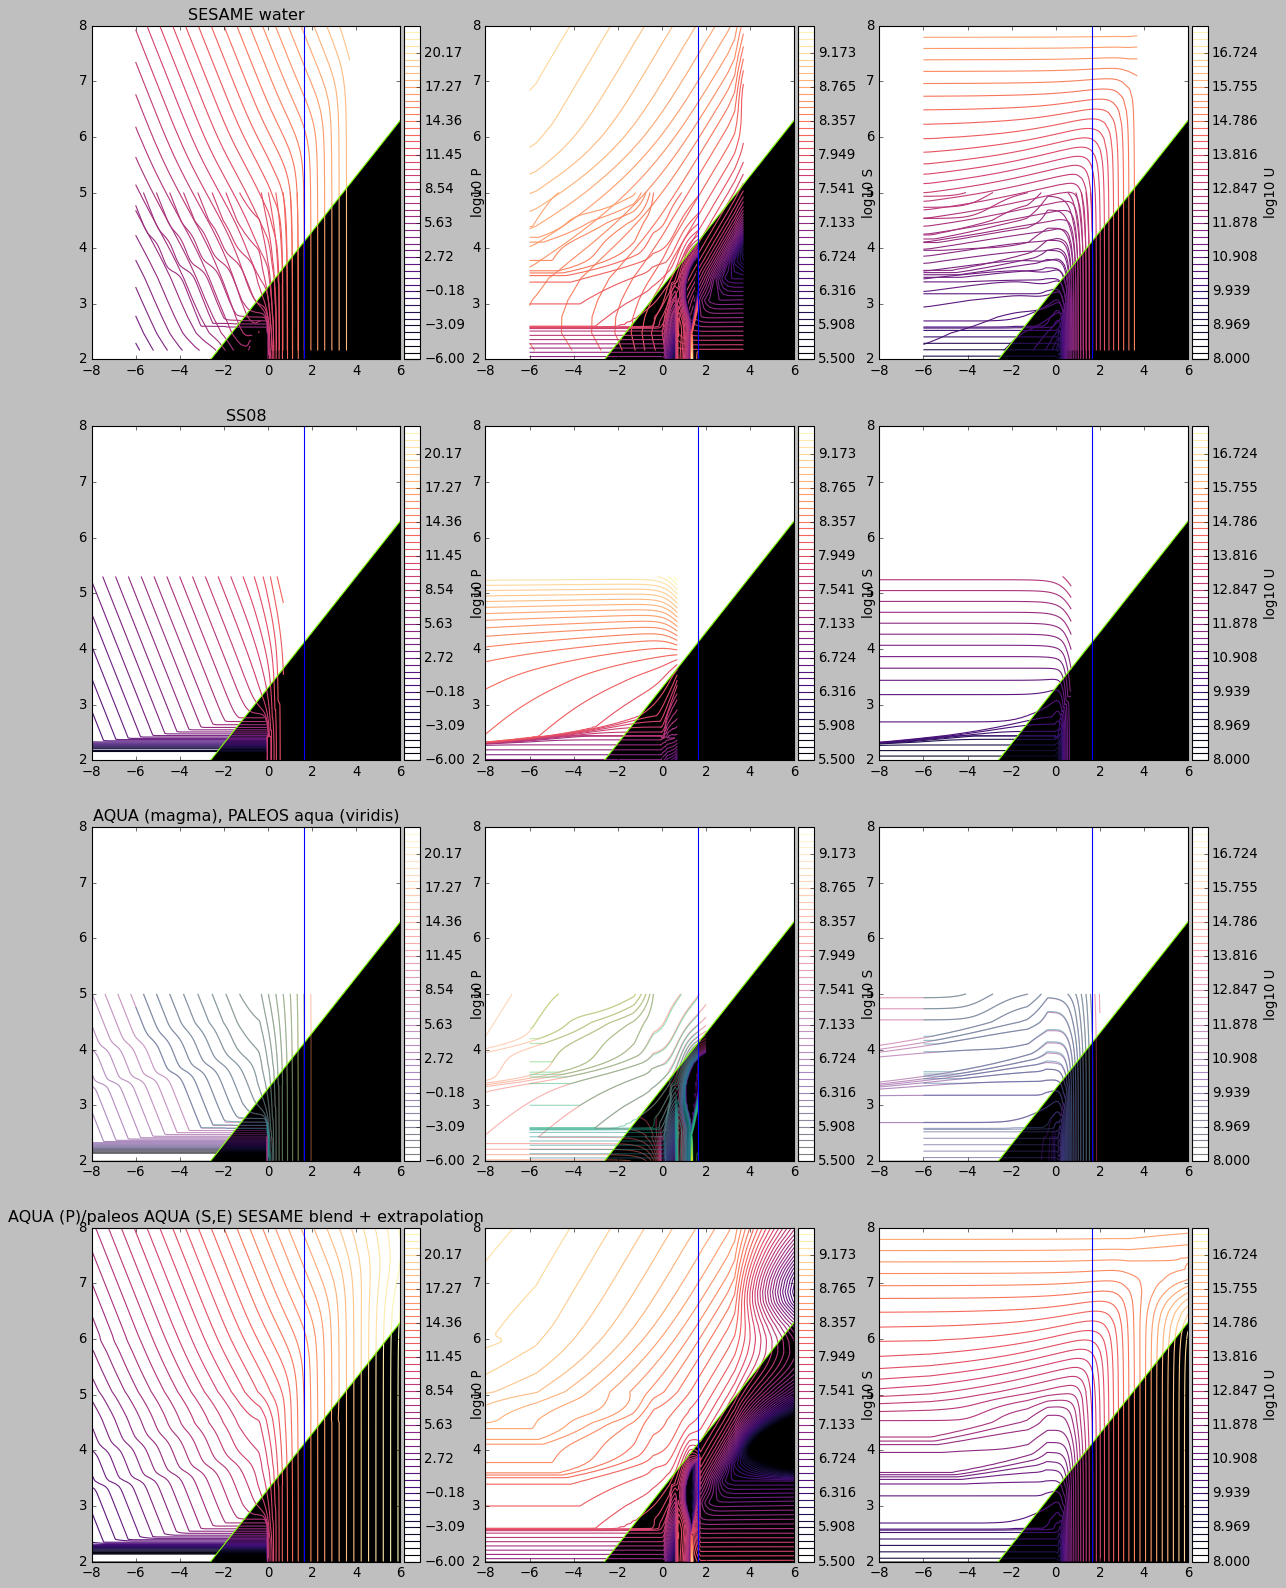

In [162]:
Pvmin = -6.
Pvmax = 22.5
Plevels = np.linspace(Pvmin, Pvmax, 50)

Svmin = 5.5
Svmax = 9.5
Slevels = np.linspace(Svmin, Svmax, 50)

Uvmin = 8.
Uvmax = 17.5
Ulevels = np.linspace(Uvmin, Uvmax, 50)

fig, axes  = plt.subplots(4,3,figsize=(18,24))

# row 0: SESAME H2O
divider00 = make_axes_locatable(axes[0,0])
cax00 = divider00.append_axes('right', size='5%', pad=0.05)
cs00 = axes[0,0].contour(h2o.log10rhogrid, h2o.log10Tgrid, h2o.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
fig.colorbar(cs00, cax=cax00, orientation='vertical',label='log10 P')

divider01 = make_axes_locatable(axes[0,1])
cax01 = divider01.append_axes('right', size='5%', pad=0.05)
cs01 = axes[0,1].contour(h2o.log10rhogrid, h2o.log10Tgrid, h2o.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
fig.colorbar(cs01, cax=cax01, orientation='vertical',label='log10 S')

divider02 = make_axes_locatable(axes[0,2])
cax02 = divider02.append_axes('right', size='5%', pad=0.05)
cs02 = axes[0,2].contour(h2o.log10rhogrid, h2o.log10Tgrid, h2o.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
fig.colorbar(cs02, cax=cax02, orientation='vertical',label='log10 U')

# row 1: SS08 H2O
divider10 = make_axes_locatable(axes[1,0])
cax10 = divider10.append_axes('right', size='5%', pad=0.05)
cs10 = axes[1,0].contour(ss08.log10rhogrid, ss08.log10Tgrid, ss08.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
fig.colorbar(cs10, cax=cax10, orientation='vertical',label='log10 P')

divider11 = make_axes_locatable(axes[1,1])
cax11 = divider11.append_axes('right', size='5%', pad=0.05)
cs11 = axes[1,1].contour(ss08.log10rhogrid, ss08.log10Tgrid, ss08.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
fig.colorbar(cs11, cax=cax11, orientation='vertical',label='log10 S')

divider12 = make_axes_locatable(axes[1,2])
cax12 = divider12.append_axes('right', size='5%', pad=0.05)
cs12 = axes[1,2].contour(ss08.log10rhogrid, ss08.log10Tgrid, ss08.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
fig.colorbar(cs12, cax=cax12, orientation='vertical',label='log10 U')

# row 2: AQUA H2O
divider20 = make_axes_locatable(axes[2,0])
cax20 = divider20.append_axes('right', size='5%', pad=0.05)
cs20 = axes[0,0].contour(paqua.log10rhogrid, paqua.log10Tgrid, paqua.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
cs20 = axes[2,0].contour(aqua.log10rhogrid, aqua.log10Tgrid, aqua.log10Pgrid, levels=Plevels, cmap='magma',alpha=0.5,vmin=Pvmin, vmax=Pvmax)
axes[2,0].contour(paqua.log10rhogrid, paqua.log10Tgrid, paqua.log10Pgrid, levels=Plevels, cmap='viridis',alpha=0.5,vmin=Pvmin, vmax=Pvmax)

fig.colorbar(cs20, cax=cax20, orientation='vertical',label='log10 P')

divider21 = make_axes_locatable(axes[2,1])
cax21 = divider21.append_axes('right', size='5%', pad=0.05)
cs21 = axes[0,1].contour(paqua.log10rhogrid, paqua.log10Tgrid, paqua.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
cs21 = axes[2,1].contour(aqua.log10rhogrid, aqua.log10Tgrid, aqua.log10Sgrid, levels=Slevels, cmap='magma',alpha=0.5,vmin=Svmin, vmax=Svmax)
axes[2,1].contour(paqua.log10rhogrid, paqua.log10Tgrid, paqua.log10Sgrid, levels=Slevels, cmap='viridis',alpha=0.5,vmin=Svmin, vmax=Svmax)

fig.colorbar(cs21, cax=cax21, orientation='vertical',label='log10 S')

divider22 = make_axes_locatable(axes[2,2])
cax22 = divider22.append_axes('right', size='5%', pad=0.05)
cs22 = axes[0,2].contour(paqua.log10rhogrid, paqua.log10Tgrid, paqua.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
cs22 = axes[2,2].contour(aqua.log10rhogrid, aqua.log10Tgrid, aqua.log10Ugrid, levels=Ulevels, cmap='magma',alpha=0.5,vmin=Uvmin, vmax=Uvmax)
axes[2,2].contour(paqua.log10rhogrid, paqua.log10Tgrid, paqua.log10Egrid, levels=Ulevels, cmap='viridis',alpha=0.5,vmin=Uvmin, vmax=Uvmax)

fig.colorbar(cs22, cax=cax22, orientation='vertical',label='log10 U')

# row 3: blended H2O
divider30 = make_axes_locatable(axes[3,0])
cax30 = divider30.append_axes('right', size='5%', pad=0.05)
#cs30 = axes[2,0].contour(blended_h2o.log10rhogrid, blended_h2o.log10Tgrid, blended_h2o.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
cs30 = axes[3,0].contour(blended_h2o.log10rhogrid, blended_h2o.log10Tgrid, blended_h2o.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
fig.colorbar(cs30, cax=cax30, orientation='vertical',label='log10 P')

divider31 = make_axes_locatable(axes[3,1])
cax31 = divider31.append_axes('right', size='5%', pad=0.05)
#cs31 = axes[2,1].contour(blended_h2o.log10rhogrid, blended_h2o.log10Tgrid, blended_h2o.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
cs31 = axes[3,1].contour(blended_h2o.log10rhogrid, blended_h2o.log10Tgrid, blended_h2o.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
fig.colorbar(cs31, cax=cax31, orientation='vertical',label='log10 S')

divider32 = make_axes_locatable(axes[3,2])
cax32 = divider32.append_axes('right', size='5%', pad=0.05)
#cs32 = axes[2,2].contour(blended_h2o.log10rhogrid, blended_h2o.log10Tgrid, blended_h2o.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
cs32 = axes[3,2].contour(blended_h2o.log10rhogrid, blended_h2o.log10Tgrid, blended_h2o.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
fig.colorbar(cs32, cax=cax32, orientation='vertical',label='log10 U')

axes[0,0].set_title("SESAME water")
axes[1,0].set_title("SS08")
axes[2,0].set_title("AQUA (magma), PALEOS aqua (viridis)")
axes[3,0].set_title("AQUA (P)/paleos AQUA (S,E) SESAME blend + extrapolation")

for ax in np.ravel(axes):
    ax.set_xlim(-8.,6.)
    ax.set_ylim(2.,8.)
    ax.plot(np.linspace(-8,6,50), 3.3 + (1./2.)*np.linspace(-8,6,50) + np.log10(1) - (5./3)*np.log10(1), ls='-', color='#7FFF00')
    ax.fill_between(x=np.linspace(-8,6,50), y1=2,y2=3.3 + (1./2.)*np.linspace(-8,6,50) + np.log10(1) - (5./3)*np.log10(1),color='k')
    ax.axvline(1.65)
plt.show()

In [163]:
# save blended H2O table data
outfile = open("./my_Ztables/blended_h2o.pkl","wb")
pickle.dump(blended_h2o,outfile)
outfile.close()

# Rock

In [12]:
# just extrapolate the ANEOS forsterite EoS
blended_rock  = meos.simple_table()
desired_Tarr = np.arange(2.,8.04,0.05)
desired_rhoarr=np.arange(-8.0,6.04, 0.05)

blended_rock.log10Tgrid, blended_rock.log10rhogrid = np.meshgrid(desired_Tarr, desired_rhoarr)
blended_rock.log10Pgrid = np.zeros_like(blended_rock.log10Tgrid)
blended_rock.log10Sgrid = np.zeros_like(blended_rock.log10Tgrid)
blended_rock.log10Ugrid = np.zeros_like(blended_rock.log10Tgrid)

# interpolate ANEOS forsterite for the ANEOS forsterite region
forsterite_nonan_log10Sgrid = copy.deepcopy(forsterite.log10Sgrid)
forsterite_nonan_log10Sgrid[np.isnan(forsterite_nonan_log10Sgrid)] = np.min(forsterite_nonan_log10Sgrid[~np.isnan(forsterite_nonan_log10Sgrid)])

forsterite_interp_log10P_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(forsterite.independent_arr_1, forsterite.independent_arr_2), values=forsterite.log10Pgrid.T, bounds_error=False, fill_value=None, method='slinear')
forsterite_interp_log10S_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(forsterite.independent_arr_1, forsterite.independent_arr_2), values=forsterite_nonan_log10Sgrid.T, bounds_error=False, fill_value=None, method='slinear')
forsterite_interp_log10U_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(forsterite.independent_arr_1, forsterite.independent_arr_2), values=forsterite.log10Ugrid.T, bounds_error=False, fill_value=None, method='slinear')

for i, rho in enumerate(desired_rhoarr[:189]): #covering log10rho <= 1.45 
    for j, T in enumerate(desired_Tarr[:98]): # covering log10T <= 6.9
        blended_rock.log10Pgrid[i,j] = forsterite_interp_log10P_given_log10rho_log10T_slinear((rho,T))
        blended_rock.log10Sgrid[i,j] = forsterite_interp_log10S_given_log10rho_log10T_slinear((rho,T))
        blended_rock.log10Ugrid[i,j] = forsterite_interp_log10U_given_log10rho_log10T_slinear((rho,T))


# interpolate/extrapolate SESAME basalt table for the rest
basalt_nonan_log10Pgrid = copy.deepcopy(basalt.log10Pgrid)
basalt_nonan_log10Pgrid[np.isnan(basalt_nonan_log10Pgrid)] = np.min(basalt_nonan_log10Pgrid[~np.isnan(basalt_nonan_log10Pgrid)])

basalt_nonan_log10Sgrid = copy.deepcopy(basalt.log10Sgrid)
basalt_nonan_log10Sgrid[~np.isfinite(basalt_nonan_log10Sgrid)] = np.min(basalt_nonan_log10Sgrid[np.isfinite(basalt_nonan_log10Sgrid)])

print(np.min(basalt_nonan_log10Sgrid))
print(np.max(basalt_nonan_log10Sgrid))

basalt_interp_log10P_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(basalt.independent_arr_1, basalt.independent_arr_2), values=basalt_nonan_log10Pgrid.T, bounds_error=False, fill_value=None, method='slinear')
basalt_interp_log10S_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(basalt.independent_arr_1, basalt.independent_arr_2), values=basalt_nonan_log10Sgrid.T, bounds_error=False, fill_value=None, method='slinear')
basalt_interp_log10U_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(basalt.independent_arr_1, basalt.independent_arr_2), values=basalt.log10Ugrid.T, bounds_error=False, fill_value=None, method='slinear')


for i, rho in enumerate(desired_rhoarr[189:]):
    for j, T in enumerate(desired_Tarr):
        blended_rock.log10Pgrid[i+189,j] = basalt_interp_log10P_given_log10rho_log10T_slinear((rho,T))
        blended_rock.log10Sgrid[i+189,j] = basalt_interp_log10S_given_log10rho_log10T_slinear((rho,T))
        blended_rock.log10Ugrid[i+189,j] = basalt_interp_log10U_given_log10rho_log10T_slinear((rho,T))

for i, rho in enumerate(desired_rhoarr):
    for j, T in enumerate(desired_Tarr[98:]):
        blended_rock.log10Pgrid[i,j+98] = basalt_interp_log10P_given_log10rho_log10T_slinear((rho,T))
        blended_rock.log10Sgrid[i,j+98] = basalt_interp_log10S_given_log10rho_log10T_slinear((rho,T))
        blended_rock.log10Ugrid[i,j+98] = basalt_interp_log10U_given_log10rho_log10T_slinear((rho,T))

# in blend region: average ANEOS and SESAME
for i,rho in enumerate(desired_rhoarr[184:194]): 
    for j, T in enumerate(desired_Tarr[:98]): #covering 5 < log10T <= 8
        blended_rock.log10Pgrid[i+184,j] = (i/10)*basalt_interp_log10P_given_log10rho_log10T_slinear((rho,T)) + ((10-i)/10)*forsterite_interp_log10P_given_log10rho_log10T_slinear((rho,T))
        blended_rock.log10Sgrid[i+184,j] = (i/10)*basalt_interp_log10S_given_log10rho_log10T_slinear((rho,T)) + ((10-i)/10)*forsterite_interp_log10S_given_log10rho_log10T_slinear((rho,T))
        blended_rock.log10Ugrid[i+184,j] = (i/10)*basalt_interp_log10U_given_log10rho_log10T_slinear((rho,T)) + ((10-i)/10)*forsterite_interp_log10U_given_log10rho_log10T_slinear((rho,T))

for i,rho in enumerate(desired_rhoarr[:189]): 
    for j, T in enumerate(desired_Tarr[93:103]): #covering 5 < log10T <= 8
        blended_rock.log10Pgrid[i,j+93] = (j/10)*basalt_interp_log10P_given_log10rho_log10T_slinear((rho,T)) + ((10-j)/10)*forsterite_interp_log10P_given_log10rho_log10T_slinear((rho,T))
        blended_rock.log10Sgrid[i,j+93] = (j/10)*basalt_interp_log10S_given_log10rho_log10T_slinear((rho,T)) + ((10-j)/10)*forsterite_interp_log10S_given_log10rho_log10T_slinear((rho,T))
        blended_rock.log10Ugrid[i,j+93] = (j/10)*basalt_interp_log10U_given_log10rho_log10T_slinear((rho,T)) + ((10-j)/10)*forsterite_interp_log10U_given_log10rho_log10T_slinear((rho,T))


3.8113660834378305
9.11620223645842


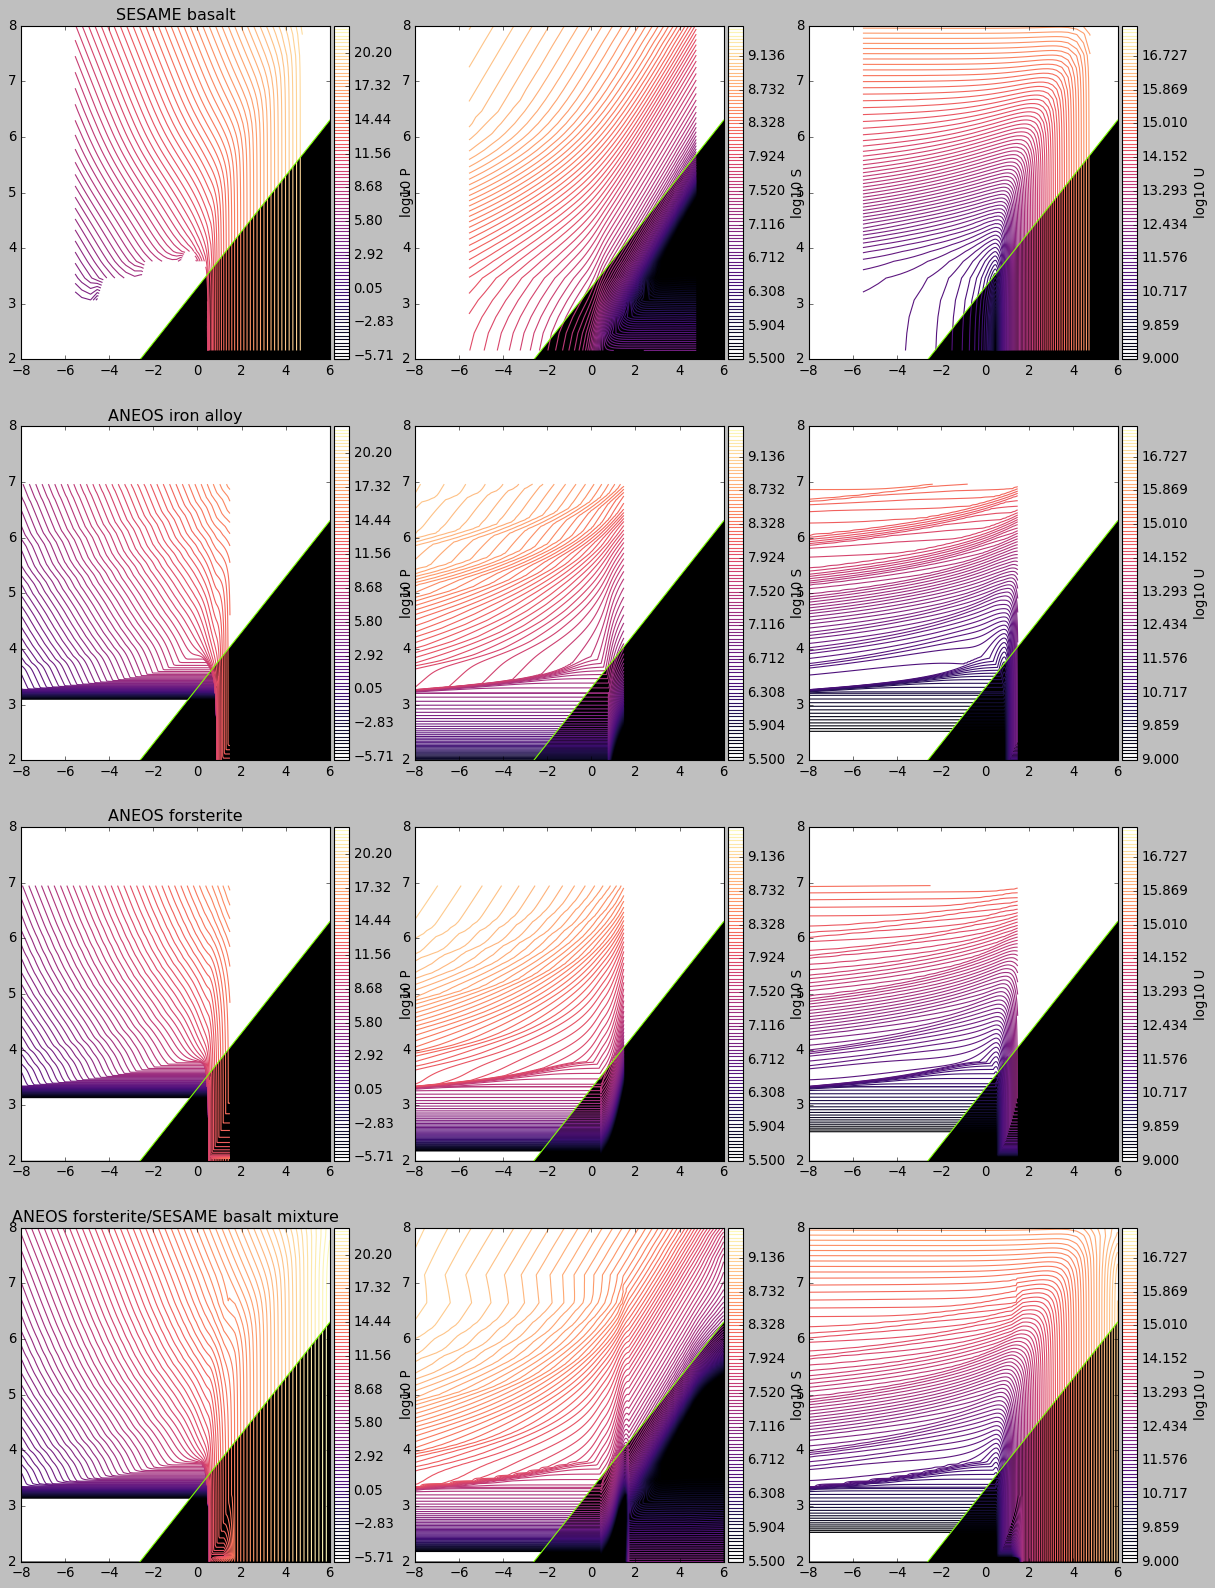

In [13]:
# rock

Pvmin = -6.
Pvmax = 22.5
Plevels = np.linspace(Pvmin, Pvmax, 100)

Svmin = 5.5
Svmax = 9.5
Slevels = np.linspace(Svmin, Svmax, 100)

Uvmin = 9
Uvmax = 17.5
Ulevels = np.linspace(Uvmin, Uvmax, 100)

fig, axes  = plt.subplots(4,3,figsize=(18,24))

# row 0: SESAME basalt
divider00 = make_axes_locatable(axes[0,0])
cax00 = divider00.append_axes('right', size='5%', pad=0.05)
cs00 = axes[0,0].contour(basalt.log10rhogrid, basalt.log10Tgrid, basalt.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
fig.colorbar(cs00, cax=cax00, orientation='vertical',label='log10 P')

divider01 = make_axes_locatable(axes[0,1])
cax01 = divider01.append_axes('right', size='5%', pad=0.05)
cs01 = axes[0,1].contour(basalt.log10rhogrid, basalt.log10Tgrid, basalt.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
fig.colorbar(cs01, cax=cax01, orientation='vertical',label='log10 S')

divider02 = make_axes_locatable(axes[0,2])
cax02 = divider02.append_axes('right', size='5%', pad=0.05)
cs02 = axes[0,2].contour(basalt.log10rhogrid, basalt.log10Tgrid, basalt.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
fig.colorbar(cs02, cax=cax02, orientation='vertical',label='log10 U')

# row 1: ANEOS iron alloy
divider10 = make_axes_locatable(axes[1,0])
cax10 = divider10.append_axes('right', size='5%', pad=0.05)
cs10 = axes[1,0].contour(iron_alloy.log10rhogrid, iron_alloy.log10Tgrid, iron_alloy.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
fig.colorbar(cs10, cax=cax10, orientation='vertical',label='log10 P')

divider11 = make_axes_locatable(axes[1,1])
cax11 = divider11.append_axes('right', size='5%', pad=0.05)
cs11 = axes[1,1].contour(iron_alloy.log10rhogrid, iron_alloy.log10Tgrid, iron_alloy.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
fig.colorbar(cs11, cax=cax11, orientation='vertical',label='log10 S')

divider12 = make_axes_locatable(axes[1,2])
cax12 = divider12.append_axes('right', size='5%', pad=0.05)
cs12 = axes[1,2].contour(iron_alloy.log10rhogrid, iron_alloy.log10Tgrid, iron_alloy.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
fig.colorbar(cs12, cax=cax12, orientation='vertical',label='log10 U')

# row 2: ANEOS forsterite
divider20 = make_axes_locatable(axes[2,0])
cax20 = divider20.append_axes('right', size='5%', pad=0.05)
cs20 = axes[2,0].contour(forsterite.log10rhogrid, forsterite.log10Tgrid, forsterite.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
#cs20 = axes[2,0].contour(aqua.log10rhogrid, aqua.log10Tgrid, aqua.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
fig.colorbar(cs20, cax=cax20, orientation='vertical',label='log10 P')

divider21 = make_axes_locatable(axes[2,1])
cax21 = divider21.append_axes('right', size='5%', pad=0.05)
cs21 = axes[2,1].contour(forsterite.log10rhogrid, forsterite.log10Tgrid, forsterite.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
#cs21 = axes[2,1].contour(aqua.log10rhogrid, aqua.log10Tgrid, aqua.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
fig.colorbar(cs21, cax=cax21, orientation='vertical',label='log10 S')

divider22 = make_axes_locatable(axes[2,2])
cax22 = divider22.append_axes('right', size='5%', pad=0.05)
cs22 = axes[2,2].contour(forsterite.log10rhogrid, forsterite.log10Tgrid, forsterite.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
#cs22 = axes[2,2].contour(aqua.log10rhogrid, aqua.log10Tgrid, aqua.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
fig.colorbar(cs22, cax=cax22, orientation='vertical',label='log10 U')

# row 3: ANEOS forsterite, extrapolated
divider30 = make_axes_locatable(axes[3,0])
cax30 = divider30.append_axes('right', size='5%', pad=0.05)
#cs30 = axes[3,0].contour(forsterite.log10rhogrid, forsterite.log10Tgrid, forsterite.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
cs30 = axes[3,0].contour(blended_rock.log10rhogrid, blended_rock.log10Tgrid, blended_rock.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
fig.colorbar(cs30, cax=cax30, orientation='vertical',label='log10 P')

divider31 = make_axes_locatable(axes[3,1])
cax31 = divider31.append_axes('right', size='5%', pad=0.05)
#cs31 = axes[3,1].contour(forsterite.log10rhogrid, forsterite.log10Tgrid, forsterite.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
cs31 = axes[3,1].contour(blended_rock.log10rhogrid, blended_rock.log10Tgrid, blended_rock.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
fig.colorbar(cs31, cax=cax31, orientation='vertical',label='log10 S')

divider32 = make_axes_locatable(axes[3,2])
cax32 = divider32.append_axes('right', size='5%', pad=0.05)
#cs32 = axes[3,2].contour(forsterite.log10rhogrid, forsterite.log10Tgrid, forsterite.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
cs32 = axes[3,2].contour(blended_rock.log10rhogrid, blended_rock.log10Tgrid, blended_rock.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
fig.colorbar(cs32, cax=cax32, orientation='vertical',label='log10 U')


axes[0,0].set_title("SESAME basalt")
axes[1,0].set_title("ANEOS iron alloy")
axes[2,0].set_title("ANEOS forsterite")
axes[3,0].set_title("ANEOS forsterite/SESAME basalt mixture")

for ax in np.ravel(axes):
    ax.set_xlim(-8.,6.)
    ax.set_ylim(2.,8.)
    ax.plot(np.linspace(-8,6,50), 3.3 + (1./2.)*np.linspace(-8,6,50) + np.log10(1) - (5./3)*np.log10(1), ls='-', color='#7FFF00')
    ax.fill_between(x=np.linspace(-8,6,50), y1=2,y2=3.3 + (1./2.)*np.linspace(-8,6,50) + np.log10(1) - (5./3)*np.log10(1),color='k')
    
plt.show()

In [14]:
# save blended rock table data
outfile = open("./my_Ztables/blended_rock.pkl","wb")
pickle.dump(blended_rock,outfile)
outfile.close()

# Iron

In [15]:
print(np.min(iron.log10rhogrid))
print(np.max(iron.log10rhogrid))

-1.2123403129026158
5.195899652409234


In [16]:
desired_Tarr = np.arange(2.,8.04,0.05)
desired_rhoarr=np.arange(-8.0,6.04, 0.05)

print(desired_Tarr[98:])


[6.9  6.95 7.   7.05 7.1  7.15 7.2  7.25 7.3  7.35 7.4  7.45 7.5  7.55
 7.6  7.65 7.7  7.75 7.8  7.85 7.9  7.95 8.  ]


In [17]:
blended_fe  = meos.simple_table()
desired_Tarr = np.arange(2.,8.04,0.05)
desired_rhoarr=np.arange(-8.0,6.04, 0.05)

blended_fe.log10Tgrid, blended_fe.log10rhogrid = np.meshgrid(desired_Tarr, desired_rhoarr)
blended_fe.log10Pgrid = np.zeros_like(blended_fe.log10Tgrid)
blended_fe.log10Sgrid = np.zeros_like(blended_fe.log10Tgrid)
blended_fe.log10Ugrid = np.zeros_like(blended_fe.log10Tgrid)


# interpolate ANEOS for the ANEOS region
aneos_nonan_log10Sgrid = copy.deepcopy(an_iron.log10Sgrid)
aneos_nonan_log10Sgrid[np.isnan(aneos_nonan_log10Sgrid)] = np.min(aneos_nonan_log10Sgrid[~np.isnan(aneos_nonan_log10Sgrid)])

aneos_interp_log10P_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(an_iron.independent_arr_1, an_iron.independent_arr_2), values=an_iron.log10Pgrid.T, bounds_error=False, fill_value=None, method='slinear')
aneos_interp_log10S_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(an_iron.independent_arr_1[0:250], an_iron.independent_arr_2[0:830]), values=aneos_nonan_log10Sgrid[:830,:250].T, bounds_error=False, fill_value=None, method='slinear')
aneos_interp_log10U_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(an_iron.independent_arr_1, an_iron.independent_arr_2), values=an_iron.log10Ugrid.T,bounds_error=False, fill_value=None, method='slinear')

for i, rho in enumerate(desired_rhoarr[:189]): # log10rho <= 1.45
    for j, T in enumerate(desired_Tarr[:98]): # log10T <= 6.9
        blended_fe.log10Pgrid[i,j] = aneos_interp_log10P_given_log10rho_log10T_slinear((rho,T))
        blended_fe.log10Ugrid[i,j] = aneos_interp_log10U_given_log10rho_log10T_slinear((rho,T))

# SESAME has no S data, so use ANEOS for the whole region
for i, rho in enumerate(desired_rhoarr): 
    for j, T in enumerate(desired_Tarr):
        blended_fe.log10Sgrid[i,j] = aneos_interp_log10S_given_log10rho_log10T_slinear((rho,T))

# interpolate SESAME for the SESAME region
sesame_nonan_log10Pgrid = copy.deepcopy(iron.log10Pgrid)
sesame_nonan_log10Pgrid[~np.isfinite(sesame_nonan_log10Pgrid)] = np.min(sesame_nonan_log10Pgrid[np.isfinite(sesame_nonan_log10Pgrid)])

# note that SESAME has no S data
sesame_interp_log10P_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(iron.independent_arr_1, iron.independent_arr_2), values=sesame_nonan_log10Pgrid.T, bounds_error=False, fill_value=None, method='slinear')
sesame_interp_log10U_given_log10rho_log10T_slinear = interpolate.RegularGridInterpolator(points=(iron.independent_arr_1, iron.independent_arr_2), values=iron.log10Ugrid.T,bounds_error=False, fill_value=None, method='slinear')

for i, rho in enumerate(desired_rhoarr[189:]): # log10rho <= 1.45
    for j, T in enumerate(desired_Tarr): # log10T <= 6.9
        blended_fe.log10Pgrid[i+189,j] = sesame_interp_log10P_given_log10rho_log10T_slinear((rho,T))
        blended_fe.log10Ugrid[i+189,j] = sesame_interp_log10U_given_log10rho_log10T_slinear((rho,T))

for i, rho in enumerate(desired_rhoarr): # log10rho <= 1.45
    for j, T in enumerate(desired_Tarr[98:]): # log10T <= 6.9
        blended_fe.log10Pgrid[i,j+98] = sesame_interp_log10P_given_log10rho_log10T_slinear((rho,T))
        blended_fe.log10Ugrid[i,j+98] = sesame_interp_log10U_given_log10rho_log10T_slinear((rho,T))

# in blend region: average ANEOS and SESAME
for i,rho in enumerate(desired_rhoarr[184:194]): 
    for j, T in enumerate(desired_Tarr[:98]): #covering 5 < log10T <= 8
        blended_fe.log10Pgrid[i+184,j] = (i/10)*sesame_interp_log10P_given_log10rho_log10T_slinear((rho,T)) + ((10-i)/10)*aneos_interp_log10P_given_log10rho_log10T_slinear((rho,T))
        blended_fe.log10Ugrid[i+184,j] = (i/10)*sesame_interp_log10U_given_log10rho_log10T_slinear((rho,T)) + ((10-i)/10)*aneos_interp_log10U_given_log10rho_log10T_slinear((rho,T))

for i,rho in enumerate(desired_rhoarr[:189]): 
    for j, T in enumerate(desired_Tarr[93:103]): #covering 5 < log10T <= 8
        blended_fe.log10Pgrid[i,j+93] = (j/10)*sesame_interp_log10P_given_log10rho_log10T_slinear((rho,T)) + ((10-j)/10)*aneos_interp_log10P_given_log10rho_log10T_slinear((rho,T))
        blended_fe.log10Ugrid[i,j+93] = (j/10)*sesame_interp_log10U_given_log10rho_log10T_slinear((rho,T)) + ((10-j)/10)*aneos_interp_log10U_given_log10rho_log10T_slinear((rho,T))


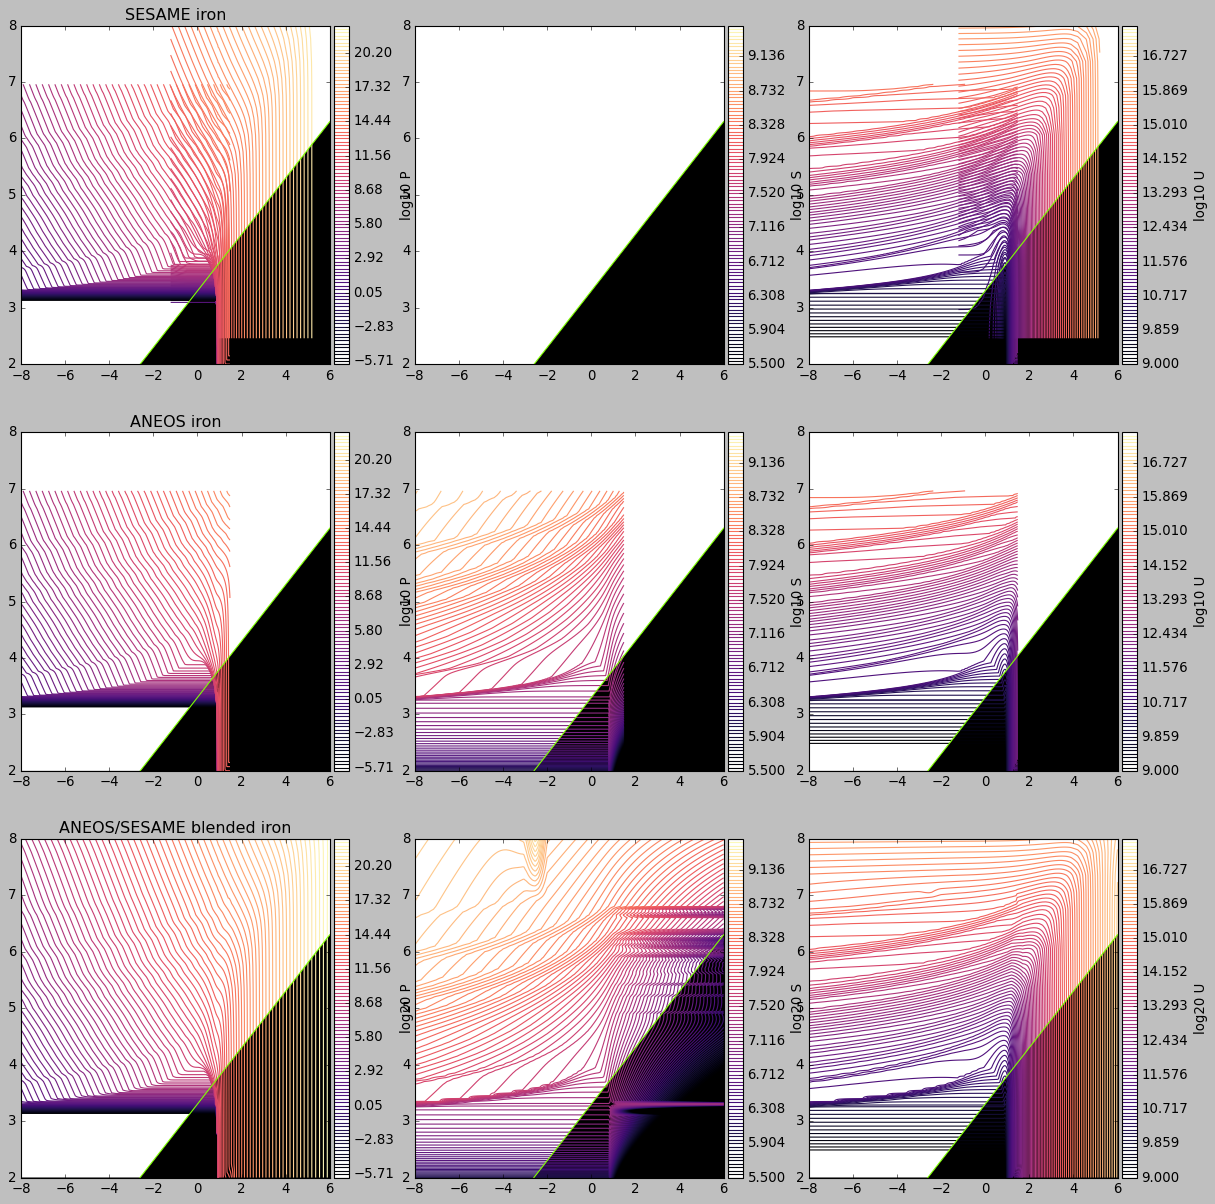

In [18]:
# iron
Pvmin = -6.
Pvmax = 22.5
Plevels = np.linspace(Pvmin, Pvmax, 100)

Svmin = 5.5
Svmax = 9.5
Slevels = np.linspace(Svmin, Svmax, 100)

Uvmin = 9
Uvmax = 17.5
Ulevels = np.linspace(Uvmin, Uvmax, 100)

fig, axes  = plt.subplots(3,3,figsize=(18,18))

# row 0: SESAME iron
divider00 = make_axes_locatable(axes[0,0])
cax00 = divider00.append_axes('right', size='5%', pad=0.05)
cs00 = axes[0,0].contour(iron.log10rhogrid, iron.log10Tgrid, iron.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
fig.colorbar(cs00, cax=cax00, orientation='vertical',label='log10 P')

divider01 = make_axes_locatable(axes[0,1])
cax01 = divider01.append_axes('right', size='5%', pad=0.05)
cs01 = axes[0,1].contour(iron.log10rhogrid, iron.log10Tgrid, iron.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
fig.colorbar(cs01, cax=cax01, orientation='vertical',label='log10 S')

divider02 = make_axes_locatable(axes[0,2])
cax02 = divider02.append_axes('right', size='5%', pad=0.05)
cs02 = axes[0,2].contour(iron.log10rhogrid, iron.log10Tgrid, iron.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
fig.colorbar(cs02, cax=cax02, orientation='vertical',label='log10 U')

# row 1: ANEOS iron
divider10 = make_axes_locatable(axes[1,0])
cax10 = divider10.append_axes('right', size='5%', pad=0.05)
cs10 = axes[1,0].contour(an_iron.log10rhogrid, an_iron.log10Tgrid, an_iron.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
cs10 = axes[0,0].contour(an_iron.log10rhogrid, an_iron.log10Tgrid, an_iron.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
fig.colorbar(cs10, cax=cax10, orientation='vertical',label='log10 P')

divider11 = make_axes_locatable(axes[1,1])
cax11 = divider11.append_axes('right', size='5%', pad=0.05)
cs11 = axes[1,1].contour(an_iron.log10rhogrid, an_iron.log10Tgrid, an_iron.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
#cs11 = axes[0,1].contour(an_iron.log10rhogrid, an_iron.log10Tgrid, an_iron.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
fig.colorbar(cs11, cax=cax11, orientation='vertical',label='log10 S')

divider12 = make_axes_locatable(axes[1,2])
cax12 = divider12.append_axes('right', size='5%', pad=0.05)
cs12 = axes[1,2].contour(an_iron.log10rhogrid, an_iron.log10Tgrid, an_iron.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
cs12 = axes[0,2].contour(an_iron.log10rhogrid, an_iron.log10Tgrid, an_iron.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
fig.colorbar(cs12, cax=cax12, orientation='vertical',label='log10 U')

# row 2: ANEOS/SESAME blend. Note that entropy is purely extrapolated from ANEOS. 
divider20 = make_axes_locatable(axes[2,0])
cax20 = divider20.append_axes('right', size='5%', pad=0.05)
cs20 = axes[2,0].contour(blended_fe.log10rhogrid, blended_fe.log10Tgrid, blended_fe.log10Pgrid, levels=Plevels, cmap='magma',alpha=1,vmin=Pvmin, vmax=Pvmax)
fig.colorbar(cs20, cax=cax20, orientation='vertical',label='log20 P')

divider21 = make_axes_locatable(axes[2,1])
cax21 = divider21.append_axes('right', size='5%', pad=0.05)
cs21 = axes[2,1].contour(blended_fe.log10rhogrid, blended_fe.log10Tgrid, blended_fe.log10Sgrid, levels=Slevels, cmap='magma',alpha=1,vmin=Svmin, vmax=Svmax)
fig.colorbar(cs21, cax=cax21, orientation='vertical',label='log20 S')

divider22 = make_axes_locatable(axes[2,2])
cax22 = divider22.append_axes('right', size='5%', pad=0.05)
cs22 = axes[2,2].contour(blended_fe.log10rhogrid, blended_fe.log10Tgrid, blended_fe.log10Ugrid, levels=Ulevels, cmap='magma',alpha=1,vmin=Uvmin, vmax=Uvmax)
fig.colorbar(cs22, cax=cax22, orientation='vertical',label='log20 U')


axes[0,0].set_title("SESAME iron")
axes[1,0].set_title("ANEOS iron")
axes[2,0].set_title("ANEOS/SESAME blended iron")

for ax in np.ravel(axes):
    ax.set_xlim(-8.,6.)
    ax.set_ylim(2.,8.)
    ax.plot(np.linspace(-8,6,50), 3.3 + (1./2.)*np.linspace(-8,6,50) + np.log10(1) - (5./3)*np.log10(1), ls='-', color='#7FFF00')
    ax.fill_between(x=np.linspace(-8,6,50), y1=2,y2=3.3 + (1./2.)*np.linspace(-8,6,50) + np.log10(1) - (5./3)*np.log10(1),color='k')
    

plt.show()

In [19]:
# save blended rock table data
outfile = open("./my_Ztables/blended_iron.pkl","wb")
pickle.dump(blended_fe,outfile)
outfile.close()